In [2]:
#### trying to make things more reproducible
import numpy as np
import random
import os
import torch

# 1. Set environment variables
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["NUMBA_NUM_THREADS"] = "1"
os.environ["NUMBA_CPU_NAME"] = "generic"
os.environ["PYTHONHASHSEED"] = "0"

# 2. Set Seeds
SEED = 0
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True, warn_only=True) 

import re
import joblib
import pandas as pd
import geopandas as gpd
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import colorcet as cc
from scipy.spatial.distance import cdist
from tqdm import tqdm
from pathlib import Path

import sys

os.environ['R_HOME'] = "../../../.pixi/envs/norkin-organoid/lib/R"
sys.path.extend(["../../scripts","../../scripts/xenium","../../scripts/xenium/morphology_code"])

import readwrite
from get_embeddings import NorkinOrganoidDataset, get_morphological_features
from preprocessing import pseudobulk
from geom_utils import classify_polygons_by_boundary_layers

cfg = readwrite.config()

## Parameters

In [3]:
scale_masks = False
standardize_scale_masks = False
correction_method = 'raw'
segmentation = 'proseg_expected'
integration_method = 'bbknn'

shapes_key = 'kmeans_morphology_scaled_15_named'
programs_key = f'leiden_0.8_{integration_method}_named'
organoid_id_column_key='component_and_cluster_and_lasso' 
organoid_size_threshold = 20


path_h5ad = cfg['results_dir']+f"xenium/integration/{correction_method}/{segmentation}/adata_malignant_{integration_method}_15.h5ad"
path_morphology_pkl = cfg['results_dir']+f"xenium/segment_organoids/proseg_expected_organoids_morphology_{standardize_scale_masks=}_{scale_masks=}.pkl"
path_morphology = cfg['results_dir']+f"xenium/segment_organoids/proseg_expected_organoids_morphology_{standardize_scale_masks=}_{scale_masks=}.parquet"
path_organoid_ids = cfg['results_dir']+"xenium/segment_organoids/organoids_ids.parquet"
path_he_features = cfg['results_dir']+"organoids_h&e/"
path_morphology_classes = cfg['xenium_metadata_dir']+"data_orgs_for_Raph.csv"
path_mutations = cfg['xenium_metadata_dir']+"mut_long.csv"
path_clinical = cfg['xenium_metadata_dir']+"xenium_39_pdo_clinical_data.csv"

condition_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'condition_palette.csv',index_col=0).iloc[:,0].to_dict()
donor_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'donor_palette.csv',index_col=0).iloc[:,0].to_dict()
gene_sets_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'gene_sets_palette.csv',index_col=0).iloc[:,0].to_dict()
cell_type_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'cell_type_palette.csv',index_col=0).iloc[:,0].to_dict()
shapes_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'shapes_palette.csv',index_col=0).iloc[:,0].to_dict()

palettes = {
    "condition": condition_palette,
    "donor_corrected": donor_palette,
    "gene_sets": gene_sets_palette,
    "cell_type": cell_type_palette,
    "shapes": shapes_palette,
    "Shapes": shapes_palette,
    "leiden_0.8_bbknn_named": gene_sets_palette,
}

# pseudobulk clustering parameters
resolutions = [0.3,0.4,0.5,0.6]
n_clusters = np.arange(4,21)

kmeans_names = {
    'kmeans_morphology_scaled_15':{
    0:"Compact",
    1:"Elongated",
    2:"Irregular",
    3:"Compact",
    4:"Branched",
    5:"Branched",
    6:"Branched",
    7:"Branched",
    8:"Irregular",
    9:"Spherical",
    10:"Spherical",
    11:"Branched",
    12:"Elongated",
    13:"Globular",
    14:"Globular"
}}

morph_features_to_keep = ['area','solidity', 'num_holes_topological', 'perimeter_sharpness','eccentricity', 'interior_holes_percentage', 'median_distance_to_edge','major_axis_length','minor_axis_length','perimeter', 'extent']
morph_features_to_exclude = ['convex_hull_blank_percentage','num_holes','interior_holes_to_object_area_percentage']
morph_features_not_to_plot = [
    'perimeter',	
    'extent',	
    'major_axis_length',
    'minor_axis_length'
]

k_morph = 'morphology_scaled'
k_he = 'he_scaled'
k_he_pca = 'he_pca'

# Read morphology results

In [4]:
# morphology per organoid
if not Path(path_morphology).exists():
    dataset = NorkinOrganoidDataset(
        organoid_cell_mapping_path=path_organoid_ids,
        organoid_id_column_key=organoid_id_column_key,
        standardize_scale=standardize_scale_masks, 
        scale=scale_masks, 
        fill=True,
        use_cached_adata=False,
        adata_save_pth=cfg['results_dir']+f'xenium/segment_organoids/ads_{scale_masks=}.pkl',
        save_path=path_morphology_pkl,
        )
    masks = [dataset[idx].squeeze() for idx in range(len(dataset))]
    morph = get_morphological_features(masks)
    df_morph = pd.DataFrame(morph,index=dataset.organoid_ids)
    df_morph.to_parquet(path_morphology)
else:
    df_morph = pd.read_parquet(path_morphology)

# organoid IDs per cell
gdf = gpd.read_parquet(path_organoid_ids)
gdf = gdf.join(df_morph,on=organoid_id_column_key).dropna()

gdf = gdf.drop(columns=morph_features_to_exclude)
df_morph = df_morph.drop(columns=morph_features_to_exclude)

# classify cells by organoid boundary layers and distance to organoid edge
output_path=Path(cfg['results_dir']+f'xenium/correlation_morphology_gex/{correction_method}/{segmentation}/classify_polygons.pkl')
if not output_path.exists():
    # gdf_sample = create_sample_gdf_with_hole()
    gdf_layers, boundaries, dissolved, statuses = classify_polygons_by_boundary_layers(
        gdf,
        cluster_col=organoid_id_column_key,
        max_layer=50,
        ignore_holes=True,
        return_distance_to_boundary=True
    )

    joblib.dump([gdf_layers, boundaries, dissolved, statuses],output_path)
else:
    gdf_layers, boundaries, dissolved, statuses = joblib.load(output_path)

gdf[organoid_id_column_key+'_cell_id'] = gdf[[organoid_id_column_key,'cell_id']].agg('_'.join, axis=1)
# gdf_layers[['segmentation','condition','panel','donor','sample','location','distance_to_boundary']].to_parquet('../../scratch/gdf_layers.parquet')

# Read morphology, mutations metadata

In [5]:
# read
df_mut = pd.read_csv(path_mutations,index_col=0)
df_clin = pd.read_csv(path_clinical)
df_morph_classes_sc = pd.read_csv(path_morphology_classes,index_col='full_id')
df_morph_classes = df_morph_classes_sc.groupby('organoid_ID').first()
df_morph_classes_manual = pd.read_csv(cfg['xenium_metadata_dir'] + 'ground_truth_morphology.csv',index_col=0)
df_morph_classes_manual.index = df_morph_classes_manual['image_name'].str.strip('.tiff')

# fix typos
donor_typos = {
    '1J2S':'1J25',
    '1B17':'1BI7',
    '0WJ3':'OWJ3',
    '0Y6H':'OY6H',
    '03F0':'03FO',
    '0UC4':'OUC4',
    '0WMY':'OWMY',
    '0YRI':'OYRI',
    '056A':'O056',
    '0UC1':'OUC1',
    '0AFN':'OAFN'
    }
df_mut['donor']=df_mut['Patient_ID'].replace(donor_typos)
df_clin['donor']=df_clin['Patient_ID'].replace(donor_typos)
df_morph_classes['donor']=df_morph_classes['donor'].replace({
    '0UC4':'OUC4', 
    '0UC1':'OUC1'
})

# reshape to wide
df_clin = pd.concat((
    df_mut.pivot(index='donor', columns='Gene', values='Status').astype('str'),
    df_mut[['donor','CMS','CRIS','MSI']].drop_duplicates().set_index('donor'),
    df_clin.set_index('donor')
    ),axis=1)



/tmp/ipykernel_3793159/1900762965.py:4: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_morph_classes_sc = pd.read_csv(path_morphology_classes,index_col='full_id')


# Read integration results

In [6]:
adata_malignant = sc.read(path_h5ad)

# Mapping CRC - CRC_PDO

In [ ]:
# shared donors
donors_crc = adata_malignant.obs.query("condition=='CRC'")["donor_corrected"].unique()
donors_crcpdo = adata_malignant.obs.query("condition=='CRC_PDO'")["donor_corrected"].unique()
shared_donors = np.intersect1d(donors_crc, donors_crcpdo)

# CAFs donors
caf_donors =  ['1DDI', '1DDI_CAFs', '07WM', '07WM_CAFs']

# join gdf for organoid info
ix_crc = adata_malignant.obs['condition']=='CRC'
adata_malignant.obs = adata_malignant.obs.join(gdf, on=None, rsuffix='_y', how='left')
adata_malignant.obs['crc_and_organoids_pb'] = adata_malignant.obs['component_and_cluster_and_lasso']
adata_malignant.obs.loc[ix_crc,'crc_and_organoids_pb'] = adata_malignant.obs.loc[ix_crc,'donor_corrected']

# pseudobulk shared
adata_malignant_shared = adata_malignant[
    adata_malignant.obs['donor_corrected'].isin(shared_donors)
    & (adata_malignant.obs['crc_and_organoids_pb'].notna())]

agg_columns=['crc_and_organoids_pb','donor_corrected','condition']
pb_crc_and_organoids = pseudobulk(
    adata_malignant_shared,agg_columns=agg_columns,
    layer='counts',key='crc_and_organoids_pb',mode='sum')
sc.pp.normalize_total(pb_crc_and_organoids,target_sum=1e4)
sc.pp.log1p(pb_crc_and_organoids)

# pseudobulk CAF
adata_malignant_caf = adata_malignant[
    adata_malignant.obs['donor_corrected'].isin(caf_donors)
    & (adata_malignant.obs['crc_and_organoids_pb'].notna())]

pb_crc_and_organoids_caf = pseudobulk(
    adata_malignant_caf,agg_columns=agg_columns,
    layer='counts',key='crc_and_organoids_pb',mode='sum')
sc.pp.normalize_total(pb_crc_and_organoids_caf,target_sum=1e4)
sc.pp.log1p(pb_crc_and_organoids_caf)

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/workflow/analysis/xenium/../../scripts/preprocessing.py:1067: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  ad.obs[key] = ad.obs[key].astype(str)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/workflow/analysis/xenium/../../scripts/preprocessing.py:1071: UserWarning: Unable to sort modes: '<' not supported between instances of 'MultiPolygon' and 'MultiPolygon'
  return x.mode()[0]
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/workflow/analysis/xenium/../../scripts/preprocessing.py:1067: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  ad.obs[key] = ad.obs[key].astype(str)
/work

### organoid pseudobulk level

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


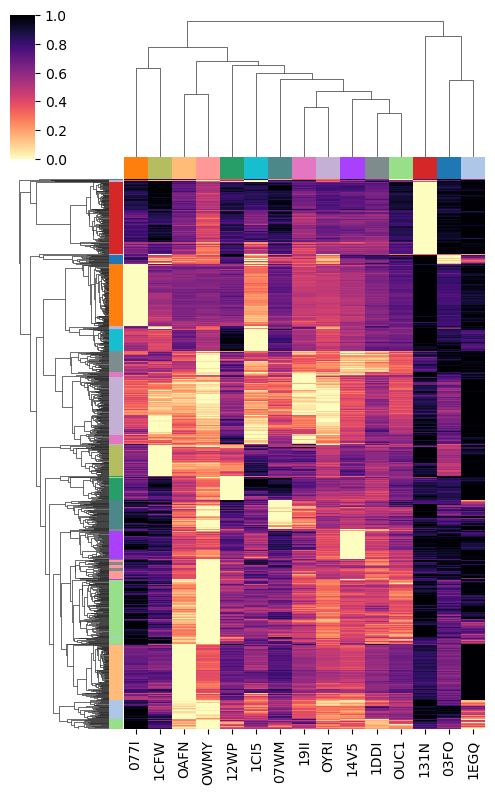

In [12]:
metric = 'correlation'

pb_organoids = pb_crc_and_organoids[pb_crc_and_organoids.obs['condition']=='CRC_PDO']
pb_crc = pb_crc_and_organoids[pb_crc_and_organoids.obs['condition']=='CRC']


D = cdist(pb_organoids.X, pb_crc.X, metric)
heatmap_data = pd.DataFrame(D,index=pb_organoids.obs_names,columns=pb_crc.obs_names)


row_donors = pb_organoids.obs['donor_corrected']
col_donors = pb_crc.obs['donor_corrected']

u_donors = np.unique(row_donors)
row_colors = [donor_palette[d] for d in row_donors]
col_colors = [donor_palette[d] for d in col_donors]

g = sns.clustermap(
    heatmap_data,
    col_colors=col_colors,     # Use the colors list for column colors
    row_colors=row_colors,     # Use the colors list for row colors
    annot=False,           # Write the distance value in the box
    fmt=".2f",            # Format to 2 decimal places
    cmap="magma_r",       # Reversed colormap: Dark/Black = Low Distance (Close), Bright = High Distance (Far)
    linecolor='white',    # Grid lines to separate cells
    yticklabels=False,
    xticklabels=True,
    standard_scale=0,
    # cbar_pos=[0., 1, .03, .4],
    figsize=(5, 8),
)

output_path = Path(cfg['figures_dir']+f'xenium/correlation_morphology_gex/{correction_method}/{segmentation}/pb_organoids_crc_{metric}_clustermap.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

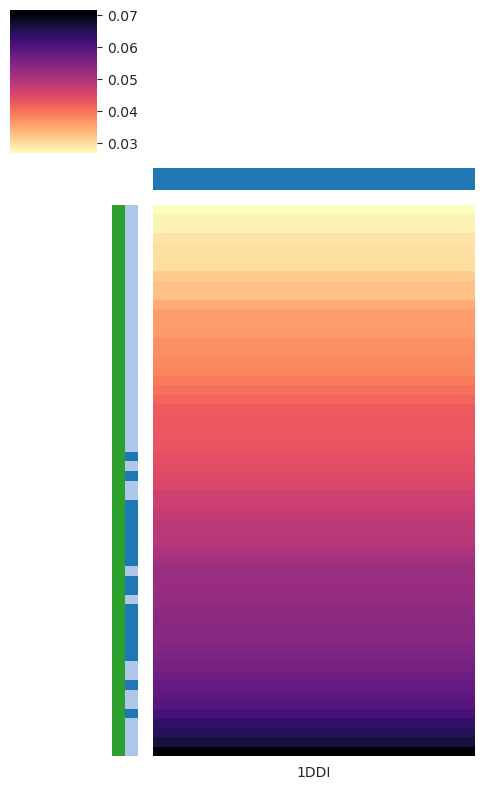

In [25]:
plot_caf_donor = ['1DDI', '1DDI_CAFs']
# plot_caf_donor = ['07WM', '07WM_CAFs']


pb_organoids = pb_crc_and_organoids_caf[
    (pb_crc_and_organoids_caf.obs['condition']=='CRC_PDO_CAF') & 
    pb_crc_and_organoids_caf.obs['donor_corrected'].isin(plot_caf_donor)]
pb_crc = pb_crc_and_organoids_caf[
    (pb_crc_and_organoids_caf.obs['condition']=='CRC') 
    & (pb_crc_and_organoids_caf.obs['donor_corrected'].isin(plot_caf_donor))
]

D = cdist(pb_organoids.X, pb_crc.X, 'cosine')
heatmap_data = pd.DataFrame(D,index=pb_organoids.obs_names,columns=pb_crc.obs_names)

row_donors = pb_organoids.obs['donor_corrected']
col_donors = pb_crc.obs['donor_corrected']

u_donors = np.unique(row_donors)
# palette_ = dict(zip(u_donors,sc.pl.palettes.default_102))
palette_ = {
    '1DDI':       '#1f77b4',  # blue
    '1DDI_CAFs':  '#aec7e8',  # light blue
    '07WM':       '#ff7f0e',  # orange
    '07WM_CAFs':  '#ffbb78',  # light orange
}

donor_colors = [palette_[d] for d in row_donors]
condition_colors = [condition_palette[d] for d in pb_organoids.obs['condition']]
row_colors = np.array([condition_colors, donor_colors])

col_colors = [palette_[d] for d in col_donors]

idx_sort = np.argsort(heatmap_data.iloc[:,0].values)

g = sns.clustermap(
    heatmap_data.iloc[idx_sort],
    col_cluster = False,
    row_cluster = False,
    col_colors=col_colors,     # Use the colors list for column colors
    row_colors=row_colors[:,idx_sort],     # Use the colors list for row colors
    annot=False,           # Write the distance value in the box
    fmt=".2f",            # Format to 2 decimal places
    cmap="magma_r",       # Reversed colormap: Dark/Black = Low Distance (Close), Bright = High Distance (Far)
    linecolor='white',    # Grid lines to separate cells
    yticklabels=False,
    xticklabels=True,
    standard_scale=None,
    # cbar_pos=[0., 1, .03, .4],
    figsize=(5, 8),
)

plt.tight_layout()
# output_path = Path(cfg['figures_dir']+f'xenium/correlation_morphology_gex/{correction_method}/{segmentation}/pb_organoids_crc_caf_euclidean_clustermap.png')
# plt.savefig(output_path, dpi=300, bbox_inches='tight')
# plt.show()

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


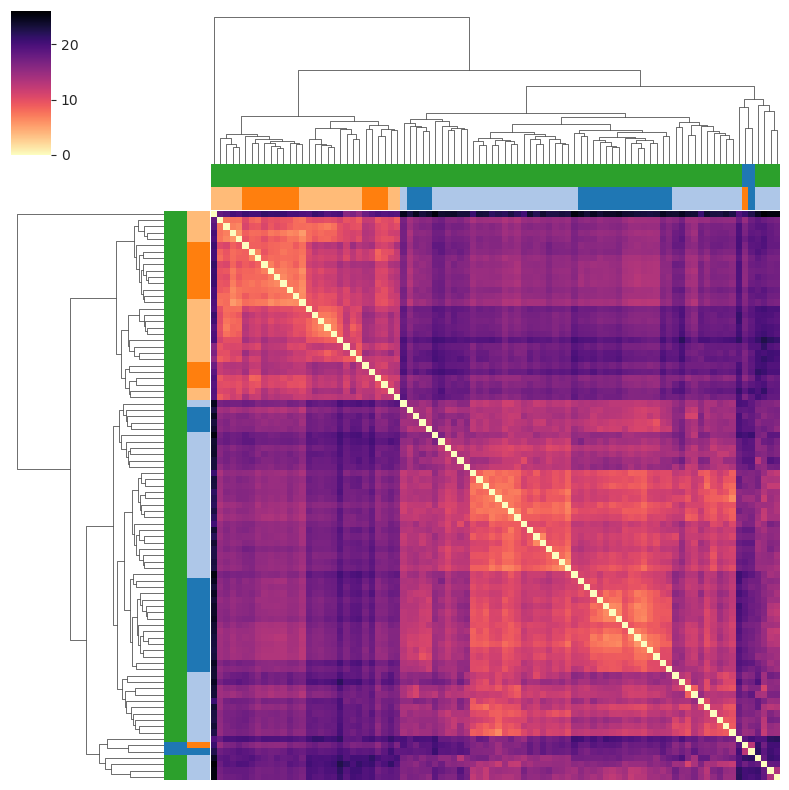

In [233]:
pb_cafs = pb_crc_and_organoids_caf[pb_crc_and_organoids_caf.obs['condition'].isin(['CRC','CRC_PDO_CAF'])]

D = cdist(pb_cafs.X, pb_cafs.X, 'euclidean')
heatmap_data = pd.DataFrame(D,index=pb_cafs.obs_names,columns=pb_cafs.obs_names)

row_donors = pb_cafs.obs['donor_corrected']
col_donors = pb_cafs.obs['donor_corrected']

u_donors = np.unique(row_donors)
palette_ = {
    '1DDI':       '#1f77b4',  # blue
    '1DDI_CAFs':  '#aec7e8',  # light blue
    '07WM':       '#ff7f0e',  # orange
    '07WM_CAFs':  '#ffbb78',  # light orange
}


donor_colors = [palette_[d] for d in row_donors]
condition_colors = [condition_palette[d] for d in pb_cafs.obs['condition']]
row_colors = [condition_colors, donor_colors]

g = sns.clustermap(
    heatmap_data,
    col_colors=row_colors,     # Use the colors list for column colors
    row_colors=row_colors,     # Use the colors list for row colors
    annot=False,           # Write the distance value in the box
    fmt=".2f",            # Format to 2 decimal places
    cmap="magma_r",       # Reversed colormap: Dark/Black = Low Distance (Close), Bright = High Distance (Far)
    linecolor='white',    # Grid lines to separate cells
    yticklabels=False,
    xticklabels=False,
    standard_scale=None,
    # cbar_pos=[0., 1, .03, .4],
    figsize=(8, 8),
)

# plt.tight_layout()
output_path = Path(cfg['figures_dir']+f'xenium/correlation_morphology_gex/{correction_method}/{segmentation}/pb_organoids_crc_caf_euclidean_clustermap.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

### cell level

In [252]:
ad_sub = sc.pp.subsample(adata_malignant_caf,n_obs=5000,random_state=0,copy=True)
ad_sub.X = ad_sub.X.toarray()

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: Th

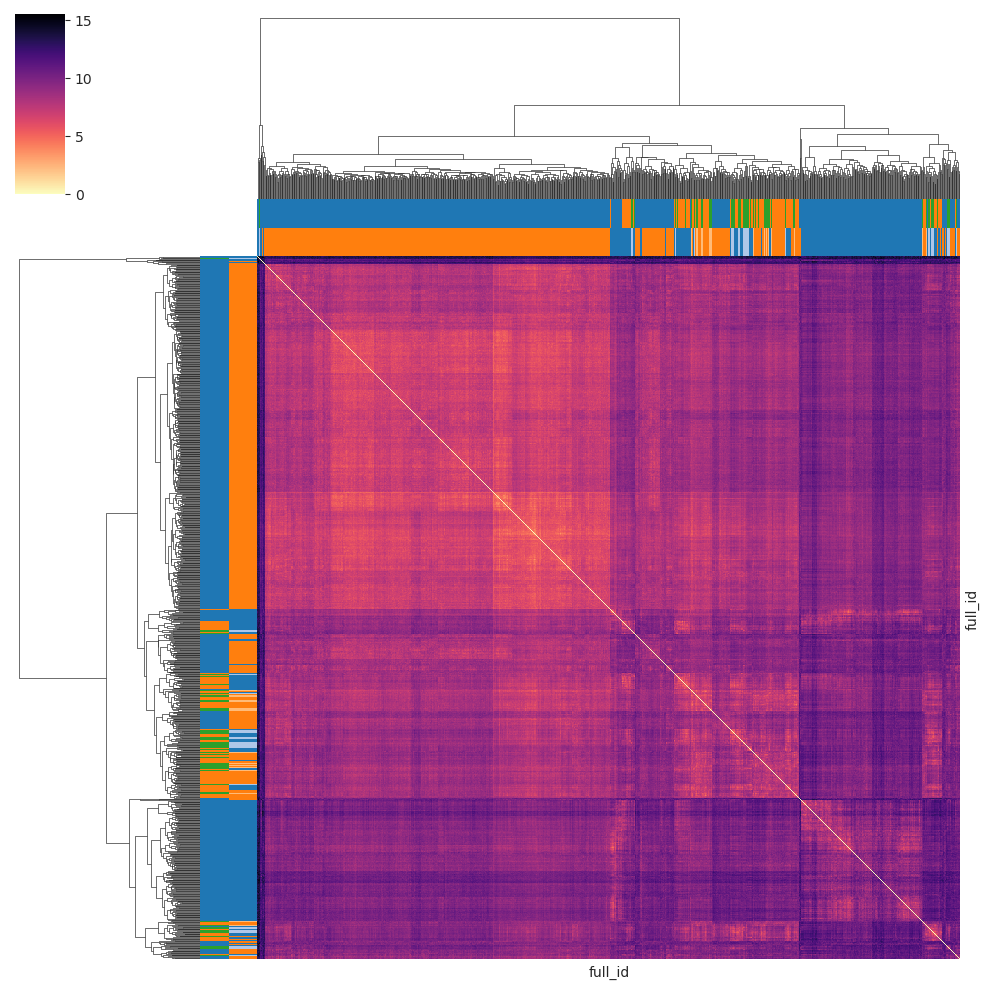

In [249]:
D = cdist(ad_sub.X, ad_sub.X, 'euclidean')
heatmap_data = pd.DataFrame(D,index=ad_sub.obs_names,columns=ad_sub.obs_names)

row_donors = ad_sub.obs['donor_corrected']
col_donors = ad_sub.obs['donor_corrected']

u_donors = np.unique(row_donors)
# palette_ = dict(zip(u_donors,sc.pl.palettes.default_102))
palette_ = {
    '1DDI':       '#1f77b4',  # blue
    '1DDI_CAFs':  '#aec7e8',  # light blue
    '07WM':       '#ff7f0e',  # orange
    '07WM_CAFs':  '#ffbb78',  # light orange
}

donor_colors = [palette_[d] for d in row_donors]
condition_colors = [condition_palette[d] for d in ad_sub.obs['condition']]
row_colors = np.array([condition_colors, donor_colors])

col_colors = [palette_[d] for d in col_donors]

idx_sort = np.argsort(heatmap_data.iloc[:,0].values)

g = sns.clustermap(
    heatmap_data,
    col_cluster = True,
    row_cluster = True,
    col_colors=row_colors,     # Use the colors list for column colors
    row_colors=row_colors,     # Use the colors list for row colors
    annot=False,           # Write the distance value in the box
    fmt=".2f",            # Format to 2 decimal places
    cmap="magma_r",       # Reversed colormap: Dark/Black = Low Distance (Close), Bright = High Distance (Far)
    linecolor='white',    # Grid lines to separate cells
    yticklabels=False,
    xticklabels=False,
    standard_scale=None,
    # cbar_pos=[0., 1, .03, .4],
    figsize=(10, 10),
)

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


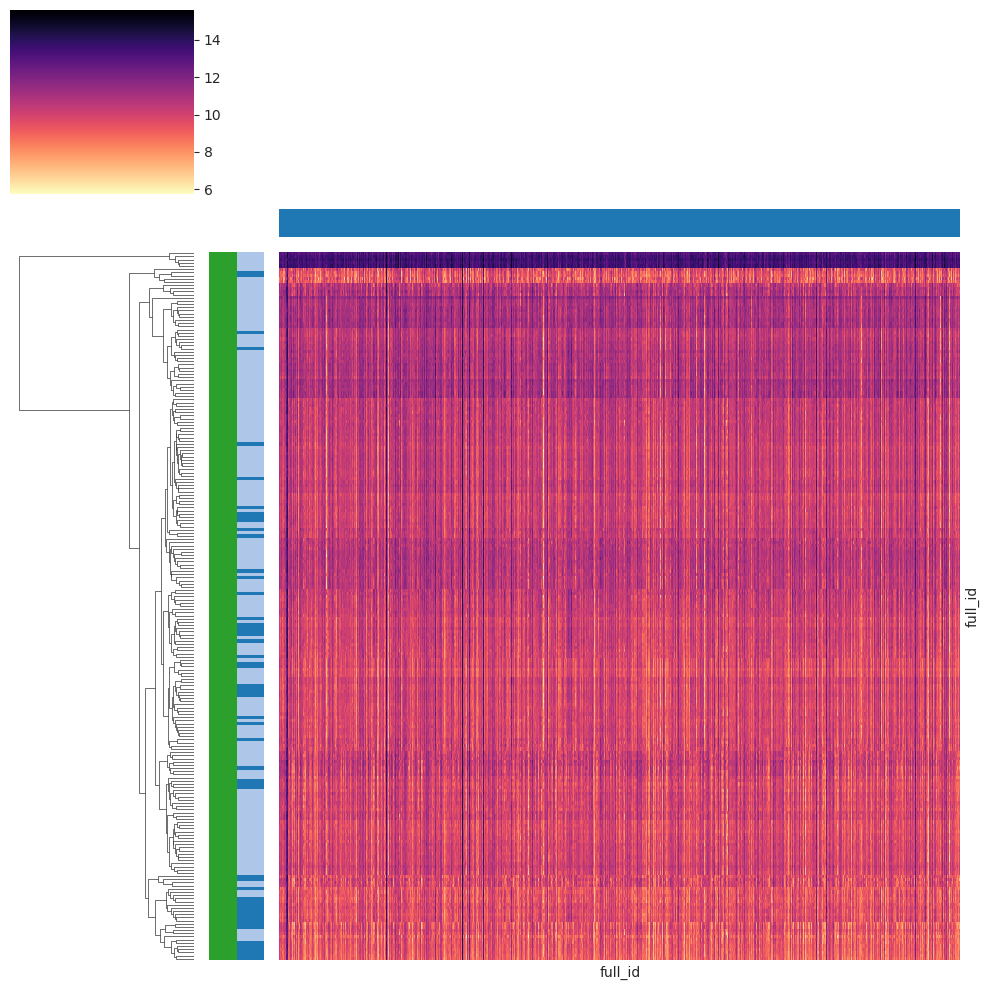

In [253]:
plot_caf_donor = ['1DDI', '1DDI_CAFs']
# plot_caf_donor = ['07WM', '07WM_CAFs']


ad_organoids = ad_sub[
    (ad_sub.obs['condition']=='CRC_PDO_CAF') & 
    ad_sub.obs['donor_corrected'].isin(plot_caf_donor)]
ad_crc = ad_sub[
    (ad_sub.obs['condition']=='CRC') 
    & (ad_sub.obs['donor_corrected'].isin(plot_caf_donor))
]

D = cdist(ad_organoids.X, ad_crc.X, 'euclidean')
heatmap_data = pd.DataFrame(D,index=ad_organoids.obs_names,columns=ad_crc.obs_names)

row_donors = ad_organoids.obs['donor_corrected']
col_donors = ad_crc.obs['donor_corrected']

u_donors = np.unique(row_donors)
# palette_ = dict(zip(u_donors,sc.pl.palettes.default_102))
palette_ = {
    '1DDI':       '#1f77b4',  # blue
    '1DDI_CAFs':  '#aec7e8',  # light blue
    '07WM':       '#ff7f0e',  # orange
    '07WM_CAFs':  '#ffbb78',  # light orange
}

donor_colors = [palette_[d] for d in row_donors]
condition_colors = [condition_palette[d] for d in ad_organoids.obs['condition']]
row_colors = np.array([condition_colors, donor_colors])

col_colors = [palette_[d] for d in col_donors]

g = sns.clustermap(
    heatmap_data,
    col_cluster = False,
    row_cluster = True,
    col_colors=col_colors,     # Use the colors list for column colors
    row_colors=row_colors,     # Use the colors list for row colors
    annot=False,           # Write the distance value in the box
    fmt=".2f",            # Format to 2 decimal places
    cmap="magma_r",       # Reversed colormap: Dark/Black = Low Distance (Close), Bright = High Distance (Far)
    linecolor='white',    # Grid lines to separate cells
    yticklabels=False,
    xticklabels=False,
    standard_scale=None,
    # cbar_pos=[0., 1, .03, .4],
    figsize=(10, 10),
)

plt.tight_layout()
# output_path = Path(cfg['figures_dir']+f'xenium/correlation_morphology_gex/{correction_method}/{segmentation}/ad_organoids_crc_caf_euclidean_clustermap.png')
# plt.savefig(output_path, dpi=300, bbox_inches='tight')
# plt.show()

# Mapping chromium - CRC_PDO

In [27]:
# load chromium, subset xneium to malignant CRC
ad_sc = sc.read_10x_h5(cfg['scrnaseq_processed_dir']+'CRC_PDO/Chromium_merged_processed/RNA_counts.h5')
ad_sc.obs = ad_sc.obs.join(pd.read_parquet(cfg['scrnaseq_processed_dir']+'CRC_PDO/Chromium_merged_processed/metadata.parquet').set_index('cell_id'))
ad_sc.obs['patient'] = ad_sc.obs['patient'].replace({'14VS': '14V5'})
ad_sc.obs['donor_corrected'] = ad_sc.obs['patient']
ad_sc.obs['condition'] = 'chromium'
ad_sc.layers['counts'] = ad_sc.X

adata_malignant_PDO = adata_malignant[adata_malignant.obs["condition"] == "CRC_PDO"].copy()
sc.pp.subsample(adata_malignant_PDO, n_obs=len(ad_sc), copy=False)

# concat modalities
genes = [adata_malignant_PDO.var_names, ad_sc.var_names]
common_genes = list(set(genes[0]).intersection(*genes[1:]))

ad_sc_crc = sc.concat({'chromium':ad_sc, 'xenium':adata_malignant_PDO}, label="modality", join="outer")[
    :, common_genes
].copy()

# subset to common donors
u = adata_malignant_PDO.obs['donor_corrected'].unique()
ad_sc_pdo_shared_donors = ad_sc_crc[ad_sc_crc.obs['donor_corrected'].isin(u)]
# ad_sc_pdo_shared_donors.obs[['condition','donor_corrected']].drop_duplicates()

# join gdf for organoid info
ix_chrom = ad_sc_pdo_shared_donors.obs['condition']=='chromium'
ad_sc_pdo_shared_donors.obs = ad_sc_pdo_shared_donors.obs.join(gdf, on=None, rsuffix='_y', how='left')
ad_sc_pdo_shared_donors.obs['chrom_and_organoids_pb'] = ad_sc_pdo_shared_donors.obs['component_and_cluster_and_lasso']
ad_sc_pdo_shared_donors.obs.loc[ix_chrom,'chrom_and_organoids_pb'] = ad_sc_pdo_shared_donors.obs.loc[ix_chrom,'donor_corrected']

# pseudobulk
agg_columns=['chrom_and_organoids_pb','donor_corrected','condition']
pb_chrom_and_organoids = pseudobulk(
    ad_sc_pdo_shared_donors,agg_columns=agg_columns,
    layer='counts',key='chrom_and_organoids_pb',mode='sum')
sc.pp.normalize_total(pb_chrom_and_organoids,target_sum=1e4)
sc.pp.log1p(pb_chrom_and_organoids)

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/workflow/analysis/xenium/../../scripts/preprocessing.py:1071: UserWarning: Unable to sort modes: '<' not supported between instances of 'MultiPolygon' and 'MultiPolygon'
  return x.mode()[0]


### organoid pseudobulk level

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


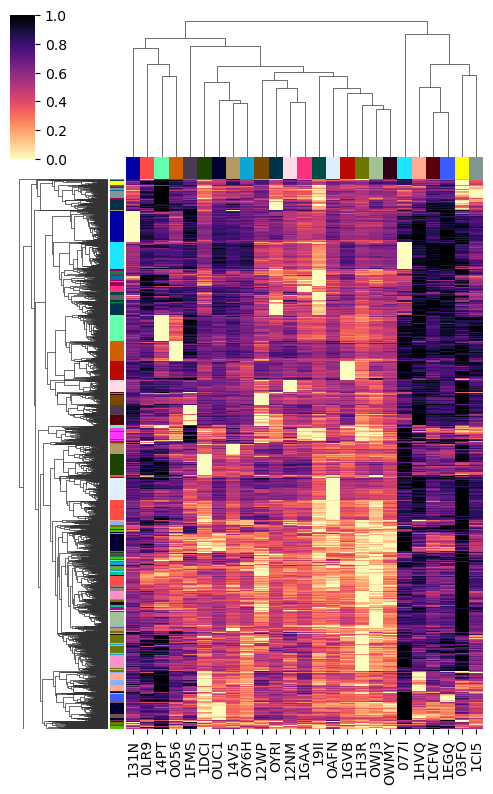

In [43]:
metric = 'correlation'

pb_organoids = pb_chrom_and_organoids[pb_chrom_and_organoids.obs['condition']=='CRC_PDO']
pb_chrom = pb_chrom_and_organoids[pb_chrom_and_organoids.obs['condition']=='chromium']


D = cdist(pb_organoids.X, pb_chrom.X, metric)
heatmap_data = pd.DataFrame(D,index=pb_organoids.obs_names,columns=pb_chrom.obs_names)

row_donors = pb_organoids.obs['donor_corrected']
col_donors = pb_chrom.obs['donor_corrected']

u_donors = np.unique(row_donors)
chrom_donor_palette = dict(zip(u_donors,sc.pl.palettes.default_102))
row_colors = [chrom_donor_palette[d] for d in row_donors]
col_colors = [chrom_donor_palette[d] for d in col_donors]

g = sns.clustermap(
    heatmap_data,
    col_colors=col_colors,     # Use the colors list for column colors
    row_colors=row_colors,     # Use the colors list for row colors
    annot=False,           # Write the distance value in the box
    fmt=".2f",            # Format to 2 decimal places
    cmap="magma_r",       # Reversed colormap: Dark/Black = Low Distance (Close), Bright = High Distance (Far)
    linecolor='white',    # Grid lines to separate cells
    yticklabels=False,
    xticklabels=True,
    standard_scale=0,
    # cbar_pos=[0., 1, .03, .4],
    figsize=(5, 8),
)

output_path = Path(cfg['figures_dir']+f'xenium/correlation_pseudobulk_gex/{correction_method}/{segmentation}/pb_organoids_chrom_{metric}_clustermap.png')
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.savefig(output_path.with_suffix('.pdf'), dpi=300, bbox_inches='tight')
plt.show()
heatmap_data.to_csv(output_path.with_suffix('.csv'))

# Score differentiation

In [37]:
import decoupler as dc

In [2]:
adata_malignant = sc.read(path_h5ad)

# shared donors
donors_crc = adata_malignant.obs.query("condition=='CRC'")["donor_corrected"].unique()
donors_crcpdo = adata_malignant.obs.query("condition=='CRC_PDO'")["donor_corrected"].unique()
shared_donors = np.intersect1d(donors_crc, donors_crcpdo)

# CAFs donors
caf_donors =  ['1DDI', '1DDI_CAFs', '07WM', '07WM_CAFs']

# join gdf for organoid info
ix_crc = adata_malignant.obs['condition']=='CRC'
adata_malignant.obs = adata_malignant.obs.join(gdf_layers, on=None, rsuffix='_y', how='left')

# add layers info
boundary_nums = sorted([
    int(loc.split('_')[1]) 
    for loc in gdf_layers['location'].unique() 
    if loc.startswith('boundary_')
])

for end in boundary_nums:
    start = boundary_nums[0] 

    included_labels = [f'boundary_{i}' for i in range(start, end + 1)]
    col_name = f'boundary_{start}_to_{end}'

    adata_malignant.obs[col_name] = np.where(
        adata_malignant.obs['location'].isin(included_labels),
        col_name,
        'rest'
    )

adata_malignant.obs['crc_and_organoids_pb'] = adata_malignant.obs['component_and_cluster_and_lasso']
adata_malignant.obs.loc[ix_crc,'crc_and_organoids_pb'] = adata_malignant.obs.loc[ix_crc,'donor_corrected']

adata_malignant.obs['crc_and_organoids_pb_by_location'] = adata_malignant.obs['crc_and_organoids_pb']
adata_malignant.obs.loc[~ix_crc,'crc_and_organoids_pb_by_location'] += '_'+adata_malignant.obs.loc[~ix_crc,'boundary_0_to_1']

# subset to shared donors
adata_malignant_shared = adata_malignant[
    adata_malignant.obs['donor_corrected'].isin(shared_donors)]


# pseudobulk shared donors, individual organoids
agg_columns=['crc_and_organoids_pb','donor_corrected','condition']
pb_crc_and_organoids = pseudobulk(
    adata_malignant_shared[adata_malignant_shared.obs['crc_and_organoids_pb'].notna()],agg_columns=agg_columns,
    layer='counts',key='crc_and_organoids_pb',mode='sum')
sc.pp.normalize_total(pb_crc_and_organoids,target_sum=1e4)
sc.pp.log1p(pb_crc_and_organoids)

pb_crc_and_organoids.obs = (
    pb_crc_and_organoids.obs
    .join(df_clin,on='donor_corrected')
)

# pseudobulk shared donors at donor level
pb_donor_level = pseudobulk(
    adata_malignant_shared,agg_columns=agg_columns,
    layer='counts',key='sample_corrected',mode='sum')
sc.pp.normalize_total(pb_donor_level,target_sum=1e4)
sc.pp.log1p(pb_donor_level)

# pseudobulk CAF
# adata_malignant_caf = adata_malignant[
#     adata_malignant.obs['donor_corrected'].isin(caf_donors)
#     & (adata_malignant.obs['crc_and_organoids_pb'].notna())]

# pb_crc_and_organoids_caf = pseudobulk(
#     adata_malignant_caf,agg_columns=agg_columns,
#     layer='counts',key='crc_and_organoids_pb',mode='sum')
# sc.pp.normalize_total(pb_crc_and_organoids_caf,target_sum=1e4)
# sc.pp.log1p(pb_crc_and_organoids_caf)


# # pseudobulk shared inner/outer
# agg_columns=['crc_and_organoids_pb_by_location','donor_corrected','condition']
# pb_crc_and_organoids_by_location = pseudobulk(
#     adata_malignant_shared,agg_columns=agg_columns,
#     layer='counts',key='crc_and_organoids_pb_by_location',mode='sum')
# sc.pp.normalize_total(pb_crc_and_organoids_by_location,target_sum=1e4)
# sc.pp.log1p(pb_crc_and_organoids_by_location)

# pb_crc_and_organoids_by_location.obs = (
#     pb_crc_and_organoids_by_location.obs
#     .join(df_clin,on='donor_corrected')
# )


# pb_organoids_inside = pb_crc_and_organoids_by_location[pb_crc_and_organoids_by_location.obs['boundary_0_to_1']=='rest'].copy()
# pb_organoids_outside = pb_crc_and_organoids_by_location[pb_crc_and_organoids_by_location.obs['boundary_0_to_1']!='rest'].copy()

# pb_organoids_inside.obs_names = pb_organoids_inside.obs_names.str.split('rest').str[0]
# pb_organoids_outside.obs_names = pb_organoids_outside.obs_names.str.split('boundary_0_to_1').str[0]

# shared_organoids = pb_organoids_inside.obs_names.intersection(pb_organoids_outside.obs_names)
# pb_organoids_inside = pb_organoids_inside[shared_organoids]
# pb_organoids_outside = pb_organoids_outside[shared_organoids]

# pb_organoids_ratio = pb_organoids_outside.copy()
# pb_organoids_ratio.X = (pb_organoids_inside.X+1e-9)/(pb_organoids_outside.X+1e-9)

NameError: name 'sc' is not defined

In [ ]:
gene_sets = {
    'well_diff_paper': ["CXCL14","IL2RG","CEACAM8","ACE2","SAMD3","GZMB", "CEACAM6","CLEC12A"],
    'well_diff_manual': ["TFF3", "CEACAM6", "REG4", "MUC5AC", "CDX1", "CDX2", "CEACAM8",],#"MUC2", "FABP1"
    'poorly_diff_manual': [ "SOX9", "MKI67", "CDK1", "UBE2C"]#"MYC",
}
df_gene_sets = pd.Series(gene_sets).explode().reset_index()
df_gene_sets.columns = ['source','target']

dc.mt.ulm(pb_crc_and_organoids,net=df_gene_sets,tmin=1)
dc.mt.ulm(pb_donor_level,net=df_gene_sets,tmin=1)
dc.mt.ulm(adata_malignant_shared,net=df_gene_sets,tmin=1)
adata_malignant_shared.obs = adata_malignant_shared.obs.assign(**adata_malignant_shared.obsm['score_ulm'])

### score organoids x tumors

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


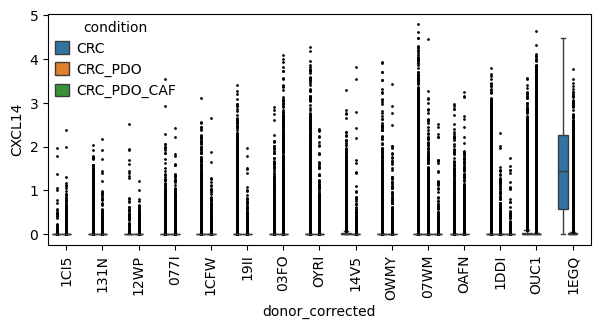

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


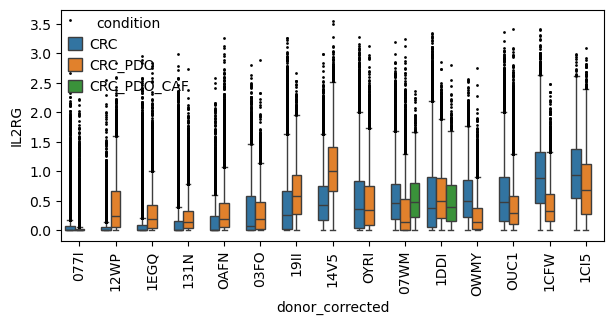

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


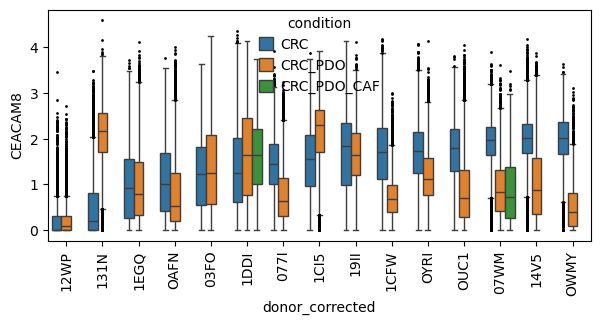

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


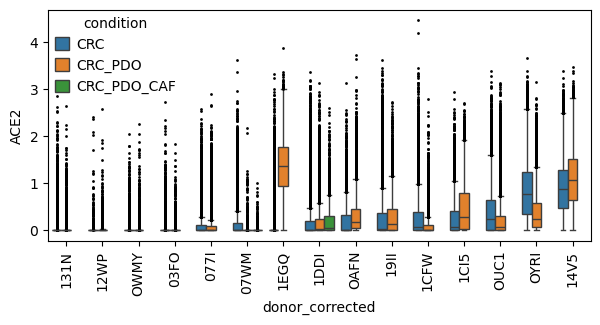

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


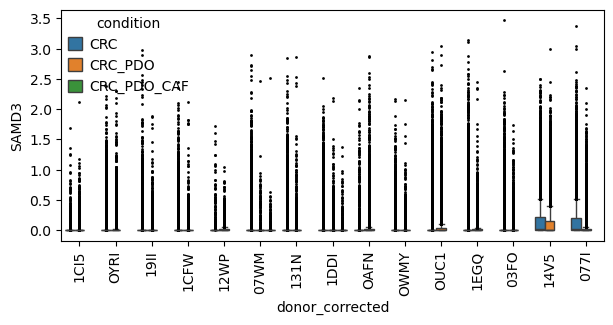

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


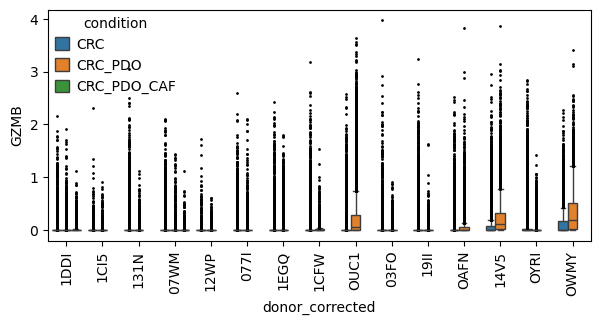

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


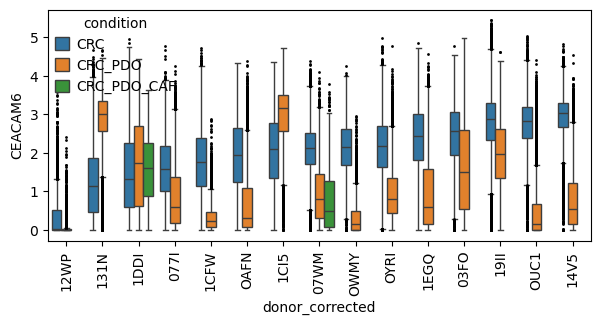

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


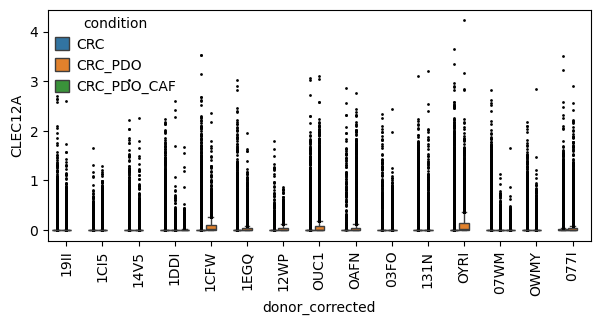

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


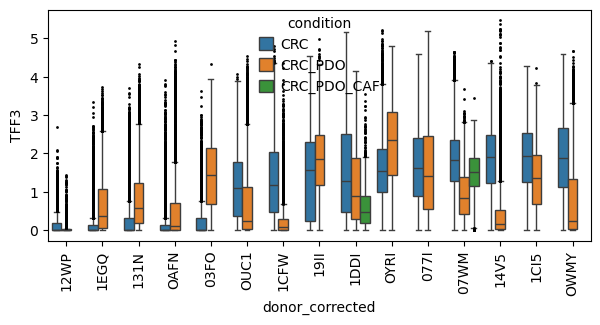

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


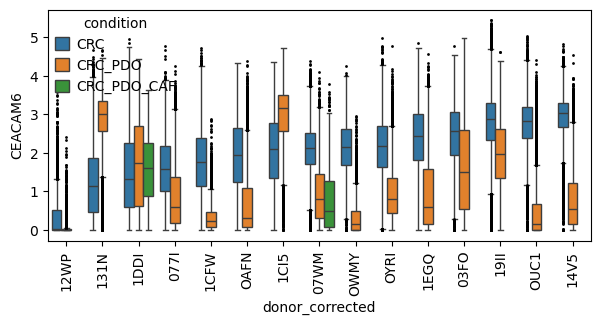

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


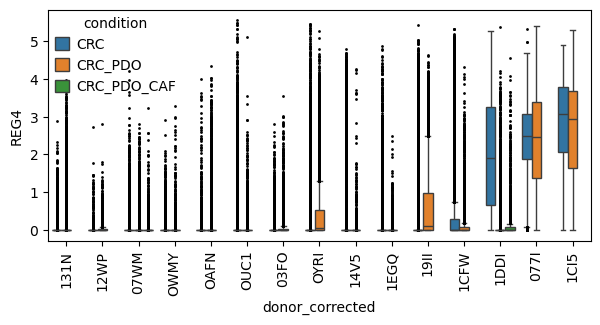

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


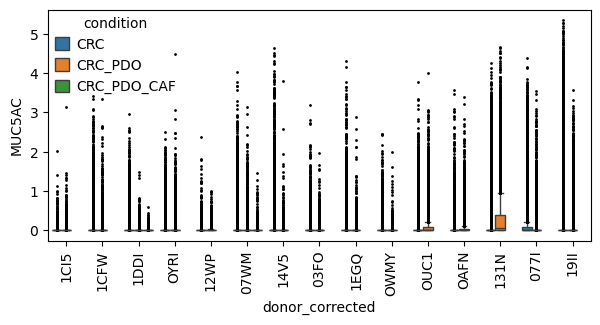

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


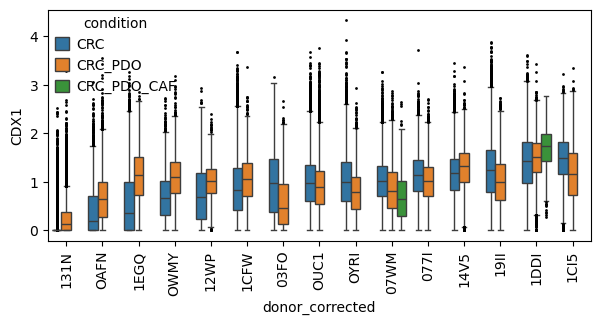

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


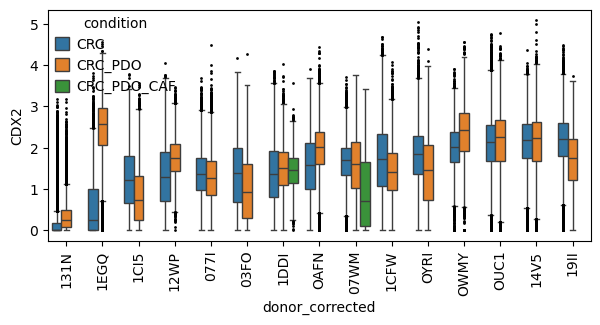

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


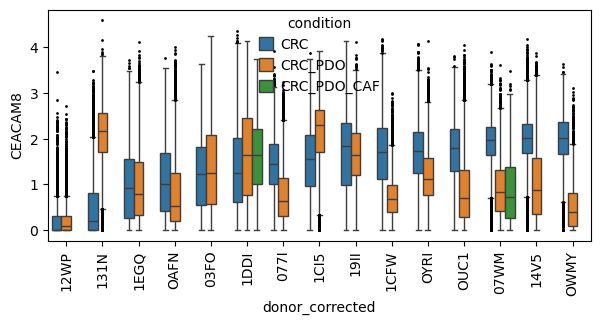

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


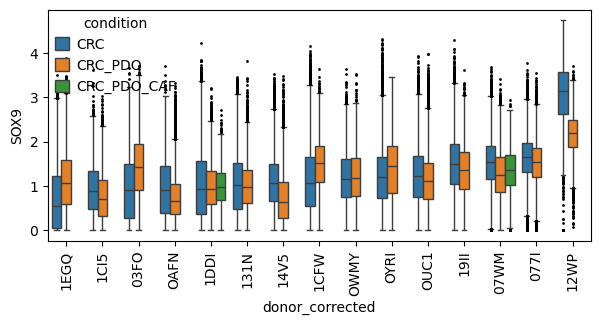

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


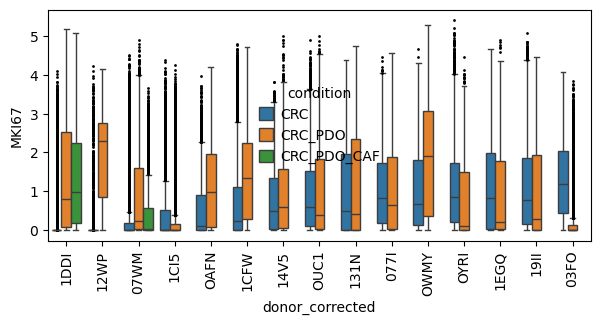

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


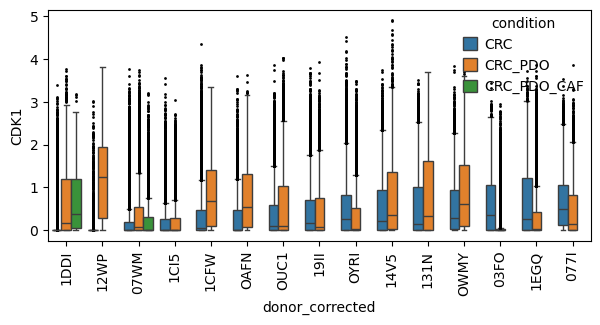

/tmp/ipykernel_1401144/3052209946.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('donor_corrected')[c]


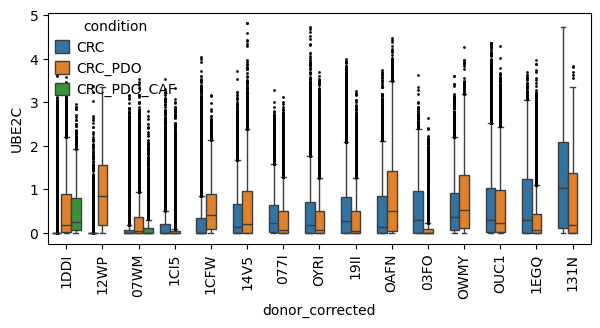

In [ ]:
c = list(gene_sets)[1]

for k,g in gene_sets.items():
    for c in g:
        # c = 'CEACAM6'
        df_plot = adata_malignant_shared.obs
        cond='CRC'

        if c in adata_malignant_shared.var_names:
            df_plot[c] = adata_malignant_shared[:,c].X.toarray().flatten()

        # compute mean y per donor
        order = (
            df_plot[df_plot['condition'] == cond]
            .groupby('donor_corrected')[c]
            .mean()
            .sort_values()
            .index
        )

        plt.figure(figsize=(7,3))
        sns.boxplot(
            data=df_plot,
            x='donor_corrected',
            y=c,
            hue='condition',
            order=order,
            flierprops = dict(marker='o', markerfacecolor='None', markersize=1,  markeredgecolor='black'),
        )
        plt.xticks(rotation=90)
        plt.show()

In [ ]:
adata_plot = adata_malignant_shared[np.random.choice(adata_malignant_shared.obs_names,50000)]

for k,g in gene_sets.items():
    print(k)
    ix_crc = adata_plot.obs['condition']=='CRC'
    sc.pl.embedding(adata_plot[ix_crc],'X_umap_bbknn',color=g,ncols=5,vmax='p95')
    sc.pl.embedding(adata_plot[~ix_crc],'X_umap_bbknn',color=g,ncols=5,vmax='p95')

sc.pl.embedding(adata_plot[ix_crc],'X_umap_bbknn',color=gene_sets.keys(),ncols=5,vmax='p95')
sc.pl.embedding(adata_plot[~ix_crc],'X_umap_bbknn',color=gene_sets.keys(),ncols=5,vmax='p95')

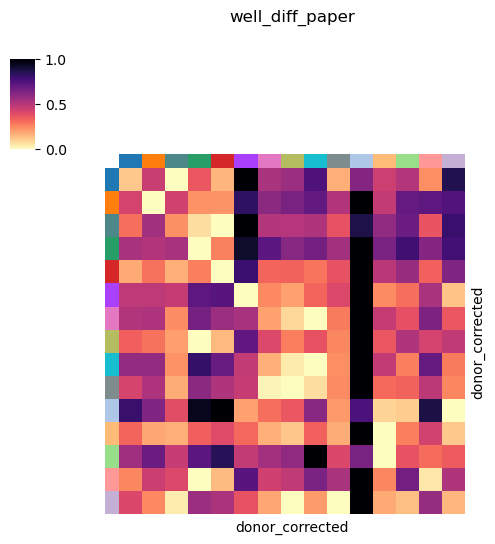

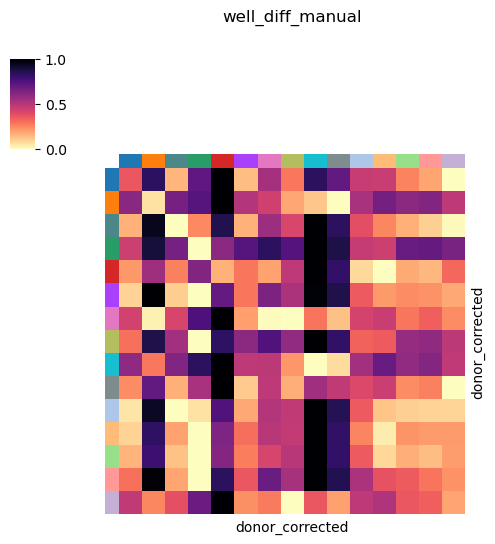

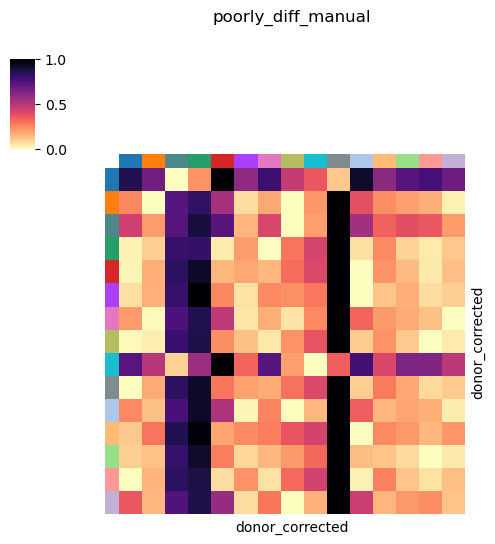

In [94]:
mean_ulm_scores = adata_malignant_shared.obs.groupby('sample_corrected')[list(gene_sets.keys())].mean()
pb_donor_level.obs = pb_donor_level.obs.drop(columns=gene_sets.keys()).join(mean_ulm_scores)

pb_organoids = pb_donor_level[pb_donor_level.obs['condition']=='CRC_PDO']
pb_crc = pb_donor_level[pb_donor_level.obs['condition']=='CRC']

# pb_organoids = pb_organoids[pb_organoids.obs['boundary_0_to_1']=='boundary_0_to_1']

for c,g in gene_sets.items():
    D = cdist(pb_organoids[:,g].X, pb_crc[:,g].X, 'euclidean')
    heatmap_data = pd.DataFrame(D,index=pb_organoids.obs_names,columns=pb_crc.obs_names)


    row_donors = pb_organoids.obs['donor_corrected']
    col_donors = pb_crc.obs['donor_corrected']
    u_donors = np.unique(row_donors)

    heatmap_data.index = row_donors
    heatmap_data.columns = col_donors
    heatmap_data = heatmap_data.loc[u_donors,u_donors]
    row_donors = heatmap_data.index
    col_donors = heatmap_data.columns

    row_colors = [donor_palette[d] for d in row_donors]
    col_colors = [donor_palette[d] for d in col_donors]



    g = sns.clustermap(
        heatmap_data,
        col_colors=col_colors,     # Use the colors list for column colors
        row_colors=row_colors,     # Use the colors list for row colors
        annot=False,           # Write the distance value in the box
        fmt=".2f",            # Format to 2 decimal places
        cmap="magma_r",       # Reversed colormap: Dark/Black = Low Distance (Close), Bright = High Distance (Far)
        linecolor='white',    # Grid lines to separate cells
        yticklabels=False,
        xticklabels=False,
        standard_scale=0,
        col_cluster=False,
        row_cluster=False,
        # cbar_pos=[0., 1, .03, .4],
        figsize=(5, 5),
    )
    g.ax_heatmap.set_title(c,y=1.4)

# # plt.tight_layout()
# output_path = Path(cfg['figures_dir']+f'xenium/correlation_morphology_gex/{correction_method}/{segmentation}/pb_organoids_crc_euclidean_clustermap.png')
# plt.savefig(output_path, dpi=300, bbox_inches='tight')
# plt.show()

### organoid pseudobulk level

In [ ]:
pb_organoids = pb_crc_and_organoids[pb_crc_and_organoids.obs['condition']=='CRC_PDO']
pb_crc = pb_crc_and_organoids[pb_crc_and_organoids.obs['condition']=='CRC']

for c,g in gene_sets.items():
    D = cdist(pb_organoids[:,g].X, pb_crc[:,g].X, 'euclidean')
    heatmap_data = pd.DataFrame(D,index=pb_organoids.obs_names,columns=pb_crc.obs_names)


    row_donors = pb_organoids.obs['donor_corrected']
    col_donors = pb_crc.obs['donor_corrected']

    u_donors = np.unique(row_donors)
    row_colors = [donor_palette[d] for d in row_donors]
    col_colors = [donor_palette[d] for d in col_donors]

    g = sns.clustermap(
        heatmap_data,
        col_colors=col_colors,     # Use the colors list for column colors
        row_colors=row_colors,     # Use the colors list for row colors
        annot=False,           # Write the distance value in the box
        fmt=".2f",            # Format to 2 decimal places
        cmap="magma_r",       # Reversed colormap: Dark/Black = Low Distance (Close), Bright = High Distance (Far)
        linecolor='white',    # Grid lines to separate cells
        yticklabels=False,
        xticklabels=True,
        standard_scale=0,
        # cbar_pos=[0., 1, .03, .4],
        figsize=(5, 8),
    )

    g.ax_heatmap.set_title(c,y=1.4)

    # plt.tight_layout()
    # output_path = Path(cfg['figures_dir']+f'xenium/correlation_morphology_gex/{correction_method}/{segmentation}/pb_organoids_crc_euclidean_clustermap.png')
    # plt.savefig(output_path, dpi=300, bbox_inches='tight')
    # plt.show()

### scores boxplots organoid x tumor

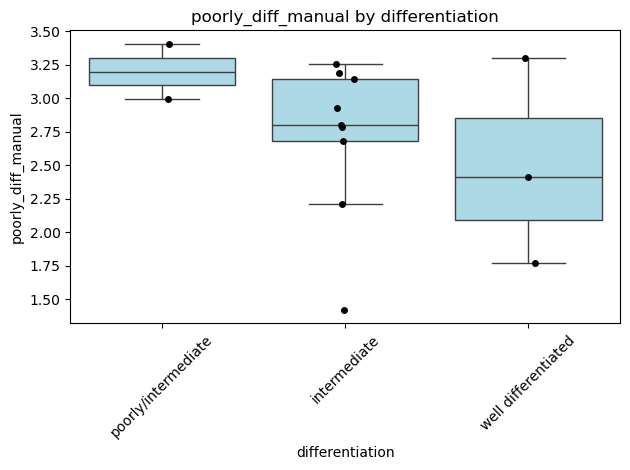

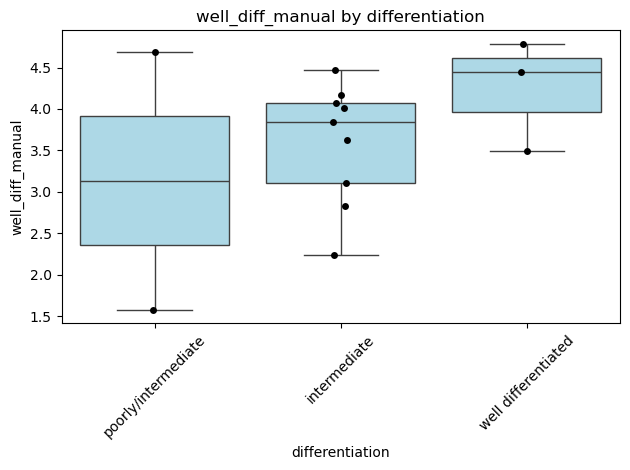

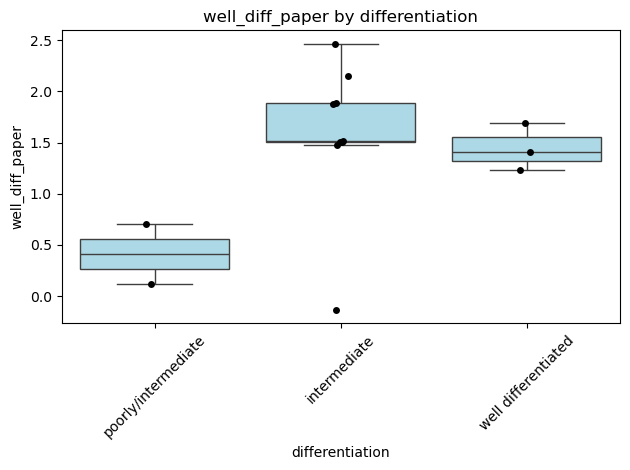

In [ ]:
pb_plot = pb_crc
df = pb_plot.obsm['score_ulm'].copy()
df['differentiation'] = pb_plot.obs['differentiation'].values

for c in pb_plot.obsm['score_ulm'].columns:
    plt.figure()
    sns.boxplot(
        data=df,
        x='differentiation',
        y=c,
        order=['poorly/intermediate', 'intermediate', 'well differentiated'],
        showfliers=False,
        boxprops={'facecolor': 'lightblue'}
    )

    sns.stripplot(
        data=df,
        x='differentiation',
        y=c,
        color='k',
        order=['poorly/intermediate', 'intermediate', 'well differentiated'],
        alpha=1,
        jitter=0.05
    )
    plt.xticks(rotation=45)
    plt.title(f'{c} by differentiation')
    plt.tight_layout()
    plt.show()


### scores pseudobulk

In [ ]:
pb_donor_level = pseudobulk(
    adata_malignant_shared,agg_columns=agg_columns,
    layer='counts',key='sample_corrected',mode='sum')
sc.pp.normalize_total(pb_donor_level,target_sum=1e4)
sc.pp.log1p(pb_donor_level)


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/workflow/analysis/xenium/../../scripts/preprocessing.py:1071: UserWarning: Unable to sort modes: '<' not supported between instances of 'MultiPolygon' and 'MultiPolygon'
  return x.mode()[0]


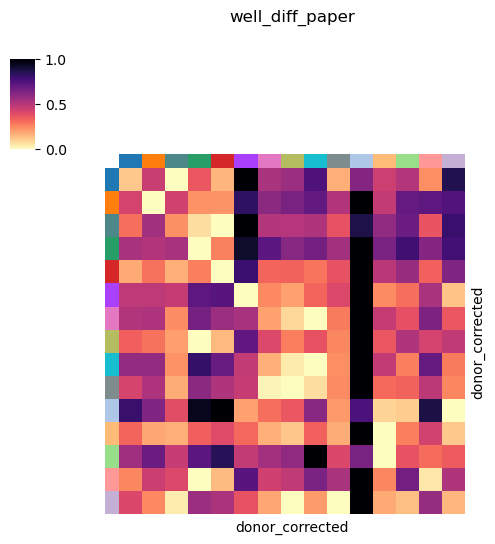

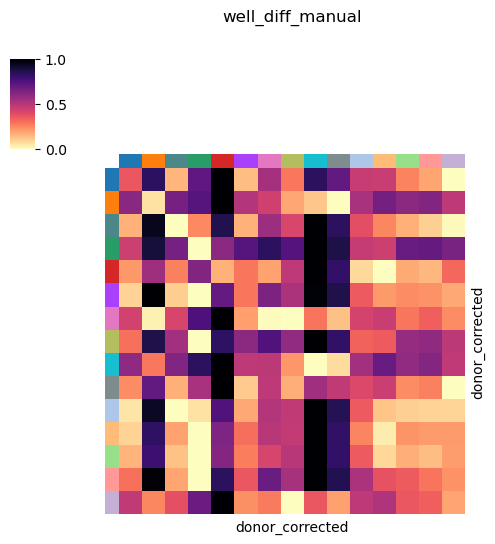

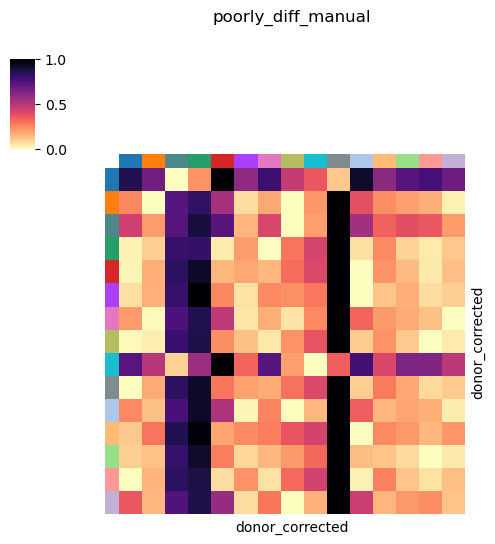

In [ ]:
pb_organoids = pb_donor_level[pb_donor_level.obs['condition']=='CRC_PDO']
pb_crc = pb_donor_level[pb_donor_level.obs['condition']=='CRC']

# pb_organoids = pb_organoids[pb_organoids.obs['boundary_0_to_1']=='boundary_0_to_1']

for c,g in gene_sets.items():
    D = cdist(pb_organoids[:,g].X, pb_crc[:,g].X, 'euclidean')
    heatmap_data = pd.DataFrame(D,index=pb_organoids.obs_names,columns=pb_crc.obs_names)


    row_donors = pb_organoids.obs['donor_corrected']
    col_donors = pb_crc.obs['donor_corrected']
    u_donors = np.unique(row_donors)

    heatmap_data.index = row_donors
    heatmap_data.columns = col_donors
    heatmap_data = heatmap_data.loc[u_donors,u_donors]
    row_donors = heatmap_data.index
    col_donors = heatmap_data.columns

    row_colors = [donor_palette[d] for d in row_donors]
    col_colors = [donor_palette[d] for d in col_donors]



    g = sns.clustermap(
        heatmap_data,
        col_colors=col_colors,     # Use the colors list for column colors
        row_colors=row_colors,     # Use the colors list for row colors
        annot=False,           # Write the distance value in the box
        fmt=".2f",            # Format to 2 decimal places
        cmap="magma_r",       # Reversed colormap: Dark/Black = Low Distance (Close), Bright = High Distance (Far)
        linecolor='white',    # Grid lines to separate cells
        yticklabels=False,
        xticklabels=False,
        standard_scale=0,
        col_cluster=False,
        row_cluster=False,
        # cbar_pos=[0., 1, .03, .4],
        figsize=(5, 5),
    )
    g.ax_heatmap.set_title(c,y=1.4)

# # plt.tight_layout()
# output_path = Path(cfg['figures_dir']+f'xenium/correlation_morphology_gex/{correction_method}/{segmentation}/pb_organoids_crc_euclidean_clustermap.png')
# plt.savefig(output_path, dpi=300, bbox_inches='tight')
# plt.show()

## correlate genes tumor vs organoid donor level

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


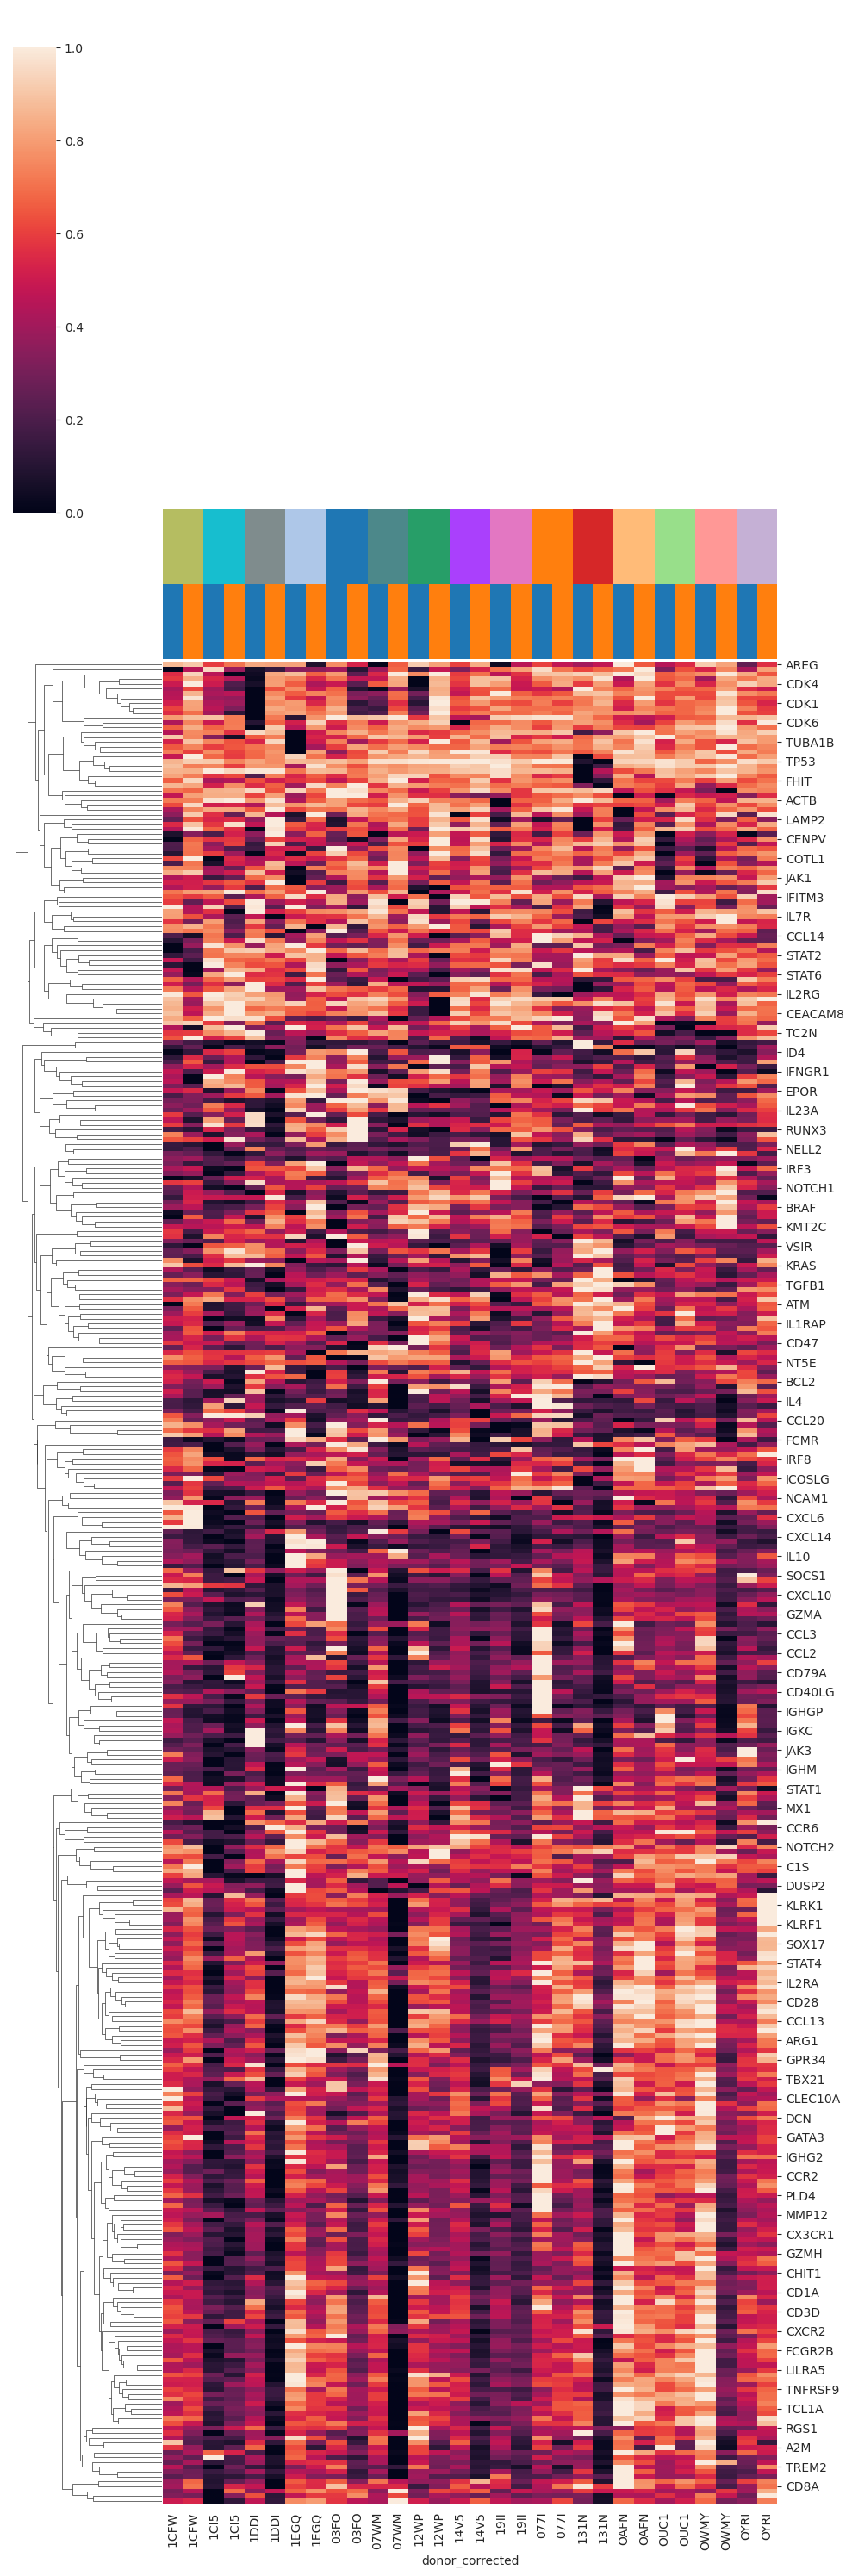

In [203]:
df_gex = pb_donor_level.to_df()
df_plot = pd.concat((df_gex,pb_donor_level.obs),axis=1)
df_plot.sort_values(['donor_corrected','condition'],inplace=True)
df_plot.index = df_plot['donor_corrected']

col_colors = [
    [palettes['donor_corrected'][d] for d in df_plot['donor_corrected']],
    [palettes['condition'][d] for d in df_plot['condition']],
    ]
sns.clustermap(df_plot[df_gex.columns].T,figsize=(10,30),col_cluster=False,col_colors=col_colors,standard_scale=0)

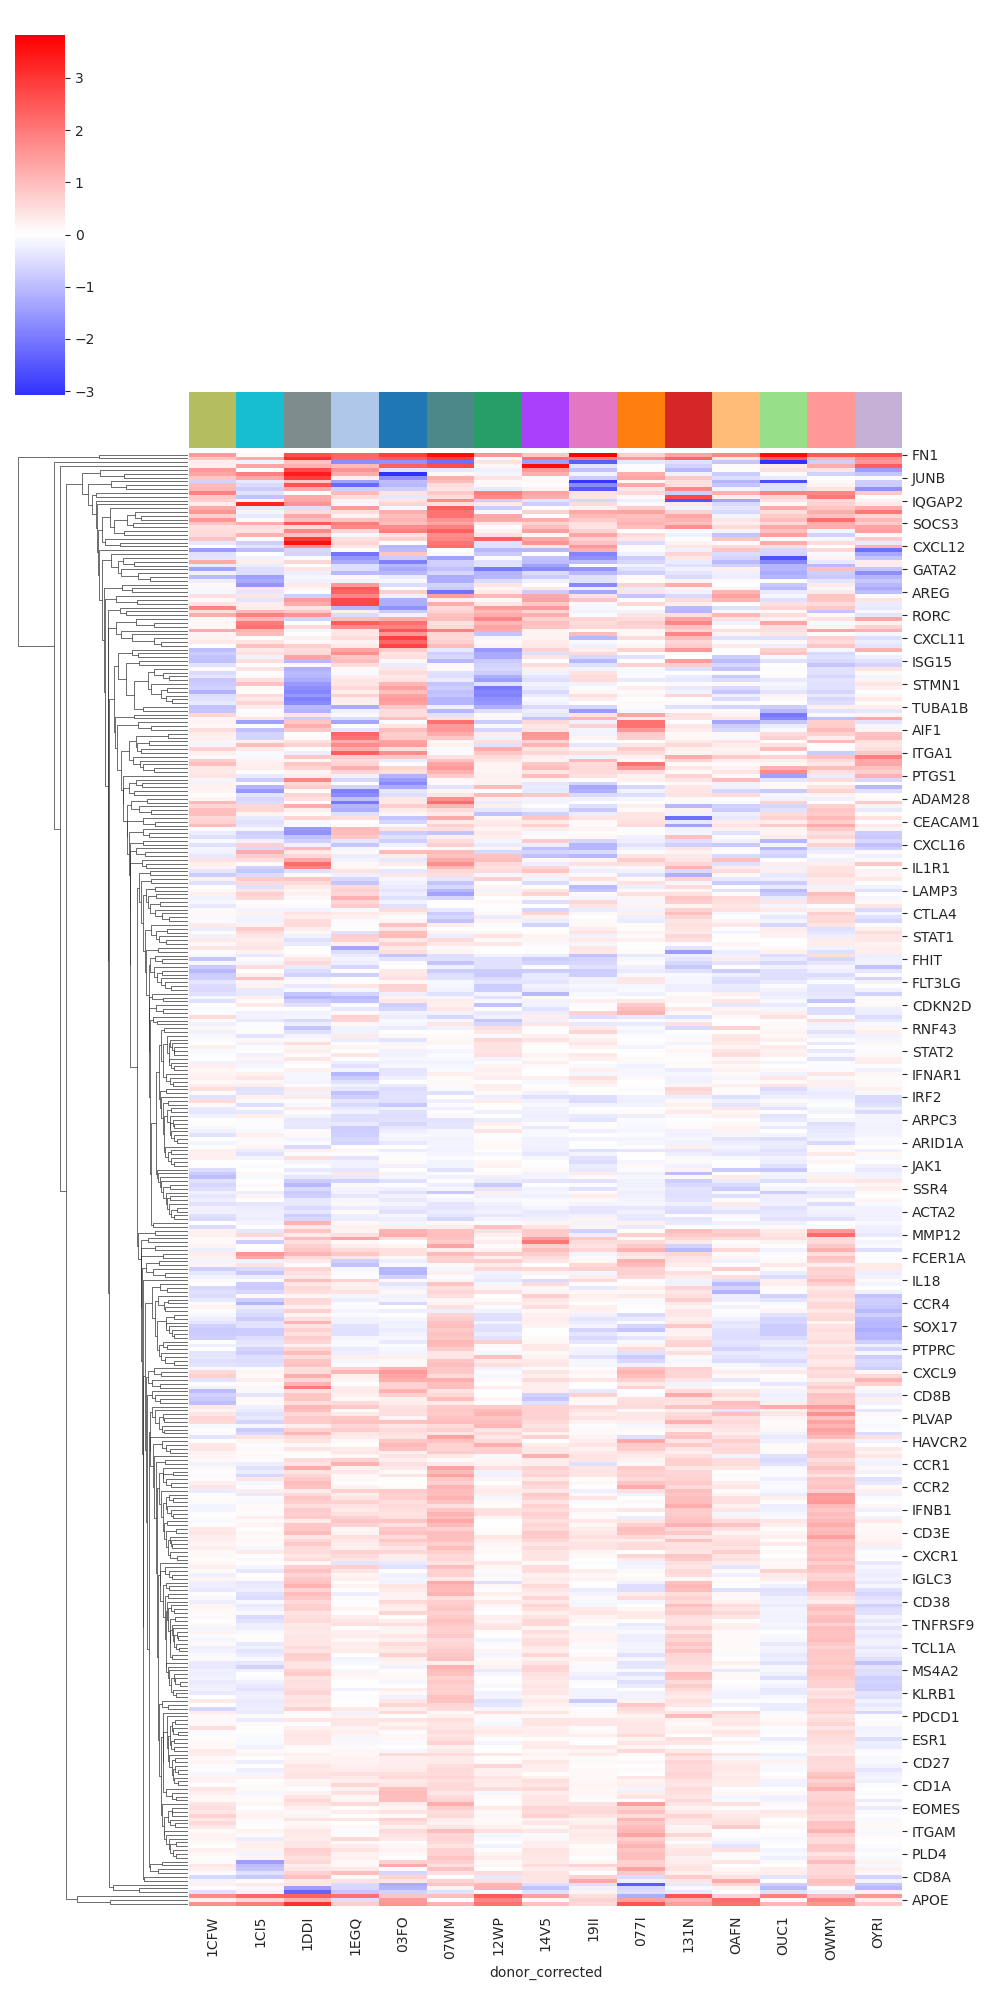

In [220]:
df_plot_crc = df_plot.query("condition == 'CRC'")
df_plot_pdo = df_plot.query("condition == 'CRC_PDO'")
df_plot_pdo = df_plot_pdo.loc[df_plot_crc.index]
df_plot_ = df_plot_crc[df_gex.columns] - df_plot_pdo[df_gex.columns]

col_colors = [
    [palettes['donor_corrected'][d] for d in df_plot_crc.index],
    ]
sns.clustermap(df_plot_.T,figsize=(10,20),col_cluster=False,col_colors=col_colors,standard_scale=None,cmap='bwr',center=0)

In [1]:
# Compute correlations (already done)
correlations = df_crc_pdo.corrwith(df_crc, method='spearman')

# Sort correlations
corr_sorted = correlations.sort_values()

# Select bottom top_n and top top_n
top_n = 40
bottom_n = corr_sorted.head(top_n)
top_n = corr_sorted.tail(top_n)

# Combine
corr_plot = pd.concat([bottom_n, top_n])

# Create a color column
colors = ['blue' if v < 0 else 'red' for v in corr_plot.values]


plt.figure(figsize=(6, 11))
sns.barplot(
    x=corr_plot.values,
    y=corr_plot.index,
    palette=colors
)

plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Spearman correlation')
plt.ylabel('')
plt.title('Top & Bottom top_n Correlated Genes\nCRC PDO vs CRC')
plt.tight_layout()
plt.show()


NameError: name 'df_crc_pdo' is not defined

In [ ]:
for k, g in gene_sets.items():
    display(correlations.loc[g].sort_values())

CLEC12A   -0.589286
SAMD3     -0.496429
GZMB      -0.203571
CEACAM6    0.014286
CEACAM8    0.017857
CXCL14     0.114286
IL2RG      0.196429
ACE2       0.400000
dtype: float64

TFF3      -0.325000
CDX1      -0.278571
CEACAM6    0.014286
CEACAM8    0.017857
MUC5AC     0.207143
REG4       0.232143
CDX2       0.239286
dtype: float64

SOX9    -0.478571
MKI67   -0.421429
UBE2C   -0.414286
CDK1    -0.400000
dtype: float64

: 